In [ ]:
!pip install -r requirements.txt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
import os
import json
import random
import shutil
import inspect
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Any

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)


os.environ["WANDB_DISABLED"] = "true"
os.environ["HF_HUB_DISABLE_XET"] = "1"


PROJECT_ROOT_CANDIDATES = [
    Path("/content/drive/MyDrive"),
    Path.cwd(),
    Path("/content/CS273-FINAL"),
    Path("/content/drive/MyDrive/CS273-FINAL"),
    Path("/content"),
]

CONFIG = {
    "model_name": "cardiffnlp/twitter-roberta-base-irony",
    "max_length": 96,
    "seed": 42,
    "n_splits": 5,
    "output_subdir": "outputs/cv_sarcasm_optuna",
    "final_model_subdir": "outputs/cv_sarcasm_optuna/final_saved_model",
    "metric_for_model_selection": "f1",
    "early_stopping_patience": 2,
    "optuna_trials": 10,
    "optuna_timeout_sec": None,  # e.g. 7200 for 2 hours
    "threshold_search_step": 0.01,
    "search_space": {
        "learning_rate": {"low": 1e-5, "high": 5e-5, "log": True},
        "batch_size": [8, 16],
        "epochs": [2, 3, 4],
        "weight_decay": {"low": 0.0, "high": 0.1, "log": False},
    },
}


@dataclass
class TextBatch:
    text: List[str]
    label: List[int]


class SarcasmDataset(Dataset):
    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_length: int) -> None:
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False,
        )
        enc["labels"] = int(self.labels[idx])
        return enc


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights: torch.Tensor | None = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.class_weights is not None:
            weight = self.class_weights.to(logits.device)
            loss_fct = nn.CrossEntropyLoss(weight=weight)
        else:
            loss_fct = nn.CrossEntropyLoss()

        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_project_root() -> Path:
    for root in PROJECT_ROOT_CANDIDATES:
        if (root / "processed_data").exists():
            return root
    raise FileNotFoundError(
        "Could not find 'processed_data' folder. Update PROJECT_ROOT_CANDIDATES for your environment."
    )


def load_data(train_path: str, val_path: str, test_path: str) -> tuple[TextBatch, TextBatch]:
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    train_val_df = pd.concat([train_df, val_df], ignore_index=True)

    for df in (train_val_df, test_df):
        df.dropna(subset=["cleaned_text", "Sarcastic"], inplace=True)
        df["cleaned_text"] = df["cleaned_text"].astype(str).str.strip()
        df["Sarcastic"] = pd.to_numeric(df["Sarcastic"], errors="coerce")
        df.dropna(subset=["Sarcastic"], inplace=True)
        df["Sarcastic"] = df["Sarcastic"].astype(int)

    valid_labels = {0, 1}
    for name, df in [("train_val", train_val_df), ("test", test_df)]:
        bad = set(df["Sarcastic"].unique()) - valid_labels
        if bad:
            raise ValueError(f"{name} contains invalid labels: {bad}. Expected only 0/1.")

    train_val = TextBatch(
        text=train_val_df["cleaned_text"].tolist(),
        label=train_val_df["Sarcastic"].tolist(),
    )
    test = TextBatch(
        text=test_df["cleaned_text"].tolist(),
        label=test_df["Sarcastic"].tolist(),
    )
    return train_val, test


def probs_from_logits(logits: np.ndarray) -> np.ndarray:
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    probs = torch.softmax(logits_tensor, dim=1).cpu().numpy()[:, 1]
    return probs


def compute_metrics_from_probs(
    probs: np.ndarray,
    labels: np.ndarray,
    threshold: float = 0.5,
) -> Dict[str, float]:
    preds = (probs >= threshold).astype(int)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    try:
        roc_auc = roc_auc_score(labels, probs)
    except ValueError:
        roc_auc = float("nan")

    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold),
    }


def find_best_threshold(
    labels: np.ndarray,
    probs: np.ndarray,
    step: float = 0.01,
) -> tuple[float, Dict[str, float]]:
    thresholds = np.arange(step, 1.0, step)

    best_threshold = 0.5
    best_metrics = compute_metrics_from_probs(probs, labels, threshold=0.5)
    best_score = best_metrics["f1"]

    for thr in thresholds:
        metrics = compute_metrics_from_probs(probs, labels, threshold=float(thr))
        score = metrics["f1"]
        if score > best_score:
            best_score = score
            best_threshold = float(thr)
            best_metrics = metrics

    return best_threshold, best_metrics


def summarize_metrics(df: pd.DataFrame) -> pd.DataFrame:
    metric_cols = [
        c for c in df.columns
        if c not in {"fold", "split"} and pd.api.types.is_numeric_dtype(df[c])
    ]
    rows = []
    for split in sorted(df["split"].unique()):
        sub = df[df["split"] == split]
        row = {"split": split}
        for col in metric_cols:
            row[f"{col}_mean"] = sub[col].mean()
            row[f"{col}_std"] = sub[col].std(ddof=1) if len(sub) > 1 else 0.0
        rows.append(row)
    return pd.DataFrame(rows)


def build_compute_metrics_fn():
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        probs = probs_from_logits(logits)
        metrics = compute_metrics_from_probs(probs, labels, threshold=0.5)
        return {
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
        }
    return compute_metrics


def build_cv_training_args(output_dir: str, params: Dict[str, Any]) -> TrainingArguments:
    kwargs = {
        "output_dir": output_dir,
        "learning_rate": params["learning_rate"],
        "per_device_train_batch_size": params["batch_size"],
        "per_device_eval_batch_size": params["batch_size"],
        "num_train_epochs": params["epochs"],
        "weight_decay": params["weight_decay"],
        "logging_steps": 50,
        "report_to": [],
        "seed": CONFIG["seed"],
        "save_total_limit": 1,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
    }

    signature = inspect.signature(TrainingArguments.__init__)

    if "evaluation_strategy" in signature.parameters:
        kwargs["evaluation_strategy"] = "epoch"
    if "eval_strategy" in signature.parameters:
        kwargs["eval_strategy"] = "epoch"
    if "save_strategy" in signature.parameters:
        kwargs["save_strategy"] = "epoch"
    if "overwrite_output_dir" in signature.parameters:
        kwargs["overwrite_output_dir"] = True
    if "logging_strategy" in signature.parameters:
        kwargs["logging_strategy"] = "steps"
    if "fp16" in signature.parameters:
        kwargs["fp16"] = torch.cuda.is_available()
    if "bf16" in signature.parameters:
        kwargs["bf16"] = False

    return TrainingArguments(**kwargs)


def build_final_training_args(output_dir: str, params: Dict[str, Any]) -> TrainingArguments:
    kwargs = {
        "output_dir": output_dir,
        "learning_rate": params["learning_rate"],
        "per_device_train_batch_size": params["batch_size"],
        "per_device_eval_batch_size": params["batch_size"],
        "num_train_epochs": params["epochs"],
        "weight_decay": params["weight_decay"],
        "logging_steps": 50,
        "report_to": [],
        "seed": CONFIG["seed"],
        "save_total_limit": 1,
    }

    signature = inspect.signature(TrainingArguments.__init__)

    if "evaluation_strategy" in signature.parameters:
        kwargs["evaluation_strategy"] = "no"
    if "eval_strategy" in signature.parameters:
        kwargs["eval_strategy"] = "no"
    if "save_strategy" in signature.parameters:
        kwargs["save_strategy"] = "no"
    if "overwrite_output_dir" in signature.parameters:
        kwargs["overwrite_output_dir"] = True
    if "logging_strategy" in signature.parameters:
        kwargs["logging_strategy"] = "steps"
    if "fp16" in signature.parameters:
        kwargs["fp16"] = torch.cuda.is_available()
    if "bf16" in signature.parameters:
        kwargs["bf16"] = False

    return TrainingArguments(**kwargs)


def make_model(model_name: str):
    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=2,
        id2label={0: "not_sarcastic", 1: "sarcastic"},
        label2id={"not_sarcastic": 0, "sarcastic": 1},
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True,
    )
    return model


def compute_class_weights_tensor(labels: List[int]) -> torch.Tensor:
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=np.array(labels),
    )
    return torch.tensor(weights, dtype=torch.float32)


def sample_params(trial: optuna.Trial) -> Dict[str, Any]:
    lr_cfg = CONFIG["search_space"]["learning_rate"]
    wd_cfg = CONFIG["search_space"]["weight_decay"]

    params = {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            lr_cfg["low"],
            lr_cfg["high"],
            log=lr_cfg["log"],
        ),
        "batch_size": trial.suggest_categorical(
            "batch_size",
            CONFIG["search_space"]["batch_size"],
        ),
        "epochs": trial.suggest_categorical(
            "epochs",
            CONFIG["search_space"]["epochs"],
        ),
        "weight_decay": trial.suggest_float(
            "weight_decay",
            wd_cfg["low"],
            wd_cfg["high"],
            log=wd_cfg["log"],
        ),
    }
    return params




def run_cv_for_params(
    X: np.ndarray,
    y: np.ndarray,
    tokenizer,
    data_collator,
    params: Dict[str, Any],
    output_dir: Path,
    trial: optuna.Trial | None = None,
) -> Dict[str, Any]:
    skf = StratifiedKFold(
        n_splits=CONFIG["n_splits"],
        shuffle=True,
        random_state=CONFIG["seed"],
    )
    splits = list(skf.split(X, y))

    fold_rows = []
    oof_probs = np.zeros(len(y), dtype=np.float32)
    oof_labels = y.copy()
    seen_mask = np.zeros(len(y), dtype=bool)

    trial_root = None
    if trial is not None:
        trial_root = output_dir / "optuna_trials" / f"trial_{trial.number}"
        trial_root.mkdir(parents=True, exist_ok=True)

    for fold, (train_idx, val_idx) in enumerate(splits, start=1):
        print(f"\n===== CV fold {fold}/{CONFIG['n_splits']} | params={params} =====")

        X_train, y_train = X[train_idx].tolist(), y[train_idx].tolist()
        X_val, y_val = X[val_idx].tolist(), y[val_idx].tolist()

        train_ds = SarcasmDataset(X_train, y_train, tokenizer, CONFIG["max_length"])
        val_ds = SarcasmDataset(X_val, y_val, tokenizer, CONFIG["max_length"])

        class_weights = compute_class_weights_tensor(y_train)
        model = make_model(CONFIG["model_name"])

        if trial_root is not None:
            fold_dir = trial_root / f"fold_{fold}"
        else:
            fold_dir = (
                output_dir
                / "cv_rebuild_best"
                / (
                    f"lr_{params['learning_rate']}_"
                    f"bs_{params['batch_size']}_"
                    f"ep_{params['epochs']}_"
                    f"wd_{params['weight_decay']}"
                )
                / f"fold_{fold}"
            )
        fold_dir.mkdir(parents=True, exist_ok=True)

        trainer = WeightedTrainer(
            model=model,
            args=build_cv_training_args(str(fold_dir), params),
            train_dataset=train_ds,
            eval_dataset=val_ds,
            data_collator=data_collator,
            compute_metrics=build_compute_metrics_fn(),
            class_weights=class_weights,
            callbacks=[
                EarlyStoppingCallback(
                    early_stopping_patience=CONFIG["early_stopping_patience"]
                )
            ],
        )

        trainer.train()

        val_pred = trainer.predict(val_ds)
        val_probs = probs_from_logits(val_pred.predictions)

        oof_probs[val_idx] = val_probs
        seen_mask[val_idx] = True

        fold_best_thr, fold_metrics = find_best_threshold(
            np.array(y_val),
            val_probs,
            step=CONFIG["threshold_search_step"],
        )

        row = {
            "fold": fold,
            "split": "val",
            "learning_rate": params["learning_rate"],
            "batch_size": params["batch_size"],
            "epochs": params["epochs"],
            "weight_decay": params["weight_decay"],
            "fold_selected_threshold": fold_best_thr,
        }
        row.update(fold_metrics)
        fold_rows.append(row)

        print(
            f"Fold {fold} val F1={fold_metrics['f1']:.4f} "
            f"| val ROC-AUC={fold_metrics['roc_auc']:.4f} "
            f"| best threshold={fold_best_thr:.2f}"
        )

        if trial is not None:
            partial_labels = oof_labels[seen_mask]
            partial_probs = oof_probs[seen_mask]
            _, partial_metrics = find_best_threshold(
                partial_labels,
                partial_probs,
                step=CONFIG["threshold_search_step"],
            )
            trial.report(partial_metrics["f1"], step=fold)

            if trial.should_prune():
                shutil.rmtree(trial_root, ignore_errors=True)
                raise optuna.TrialPruned()

        shutil.rmtree(fold_dir, ignore_errors=True)

    oof_best_threshold, oof_metrics = find_best_threshold(
        oof_labels,
        oof_probs,
        step=CONFIG["threshold_search_step"],
    )

    if trial_root is not None:
        shutil.rmtree(trial_root, ignore_errors=True)

    return {
        "params": params,
        "fold_metrics_df": pd.DataFrame(fold_rows),
        "oof_probs": oof_probs,
        "oof_labels": oof_labels,
        "oof_best_threshold": oof_best_threshold,
        "oof_metrics": oof_metrics,
    }


def train_final_model(
    train_val: TextBatch,
    test: TextBatch,
    tokenizer,
    data_collator,
    best_params: Dict[str, Any],
    selected_threshold: float,
    output_dir: Path,
) -> Dict[str, Any]:
    train_ds = SarcasmDataset(train_val.text, train_val.label, tokenizer, CONFIG["max_length"])
    test_ds = SarcasmDataset(test.text, test.label, tokenizer, CONFIG["max_length"])

    class_weights = compute_class_weights_tensor(train_val.label)
    model = make_model(CONFIG["model_name"])

    final_dir = output_dir / "final_model"
    final_dir.mkdir(parents=True, exist_ok=True)

    trainer = WeightedTrainer(
        model=model,
        args=build_final_training_args(str(final_dir), best_params),
        train_dataset=train_ds,
        data_collator=data_collator,
        compute_metrics=build_compute_metrics_fn(),
        class_weights=class_weights,
    )

    trainer.train()

    saved_model_dir = output_dir / "final_saved_model"
    saved_model_dir.mkdir(parents=True, exist_ok=True)

    trainer.save_model(str(saved_model_dir))
    tokenizer.save_pretrained(str(saved_model_dir))

    with open(saved_model_dir / "inference_config.json", "w") as f:
        json.dump(
            {
                "selected_threshold": selected_threshold,
                "max_length": CONFIG["max_length"],
                "label2id": {"not_sarcastic": 0, "sarcastic": 1},
                "id2label": {"0": "not_sarcastic", "1": "sarcastic"},
                "base_model_name": CONFIG["model_name"],
            },
            f,
            indent=2,
        )
    test_pred = trainer.predict(test_ds)
    test_probs = probs_from_logits(test_pred.predictions)
    test_labels = np.array(test.label)
    test_metrics = compute_metrics_from_probs(
        test_probs,
        test_labels,
        threshold=selected_threshold,
    )
    return {
        "trainer": trainer,
        "test_probs": test_probs,
        "test_metrics": test_metrics,
        "saved_model_dir": str(saved_model_dir)
    }


def objective_factory(X, y, tokenizer, data_collator, output_dir: Path):
    def objective(trial: optuna.Trial) -> float:
        params = sample_params(trial)
        result = run_cv_for_params(
            X=X,
            y=y,
            tokenizer=tokenizer,
            data_collator=data_collator,
            params=params,
            output_dir=output_dir,
            trial=trial,
        )

        trial.set_user_attr("params", params)
        trial.set_user_attr("oof_metrics", result["oof_metrics"])
        trial.set_user_attr("oof_best_threshold", result["oof_best_threshold"])

        return result["oof_metrics"]["f1"]
    return objective


def rebuild_best_result_from_study(
    study: optuna.Study,
    X: np.ndarray,
    y: np.ndarray,
    tokenizer,
    data_collator,
    output_dir: Path,
) -> Dict[str, Any]:
    best_params = study.best_trial.user_attrs.get("params", study.best_params)

    result = run_cv_for_params(
        X=X,
        y=y,
        tokenizer=tokenizer,
        data_collator=data_collator,
        params=best_params,
        output_dir=output_dir,
        trial=None,
    )
    return result


def main() -> None:
    project_root = resolve_project_root()
    train_csv = project_root / "processed_data" / "train_split.csv"
    val_csv = project_root / "processed_data" / "val_split.csv"
    test_csv = project_root / "processed_data" / "test_split.csv"
    output_dir = project_root / CONFIG["output_subdir"]
    output_dir.mkdir(parents=True, exist_ok=True)

    set_seed(CONFIG["seed"])

    print(f"Using project root: {project_root}")
    print(f"Base model: {CONFIG['model_name']}")

    train_val, test = load_data(str(train_csv), str(val_csv), str(test_csv))

    tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"], use_fast=True)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    X = np.array(train_val.text)
    y = np.array(train_val.label)

    print(f"Train+Val size: {len(train_val.label)}")
    print(f"Test size: {len(test.label)}")
    print(f"Positive rate in Train+Val: {np.mean(y):.4f}")
    print(f"Positive rate in Test: {np.mean(test.label):.4f}")

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=CONFIG["seed"]),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=2),
        study_name="sarcasm_cv_f1_optimization",
    )

    study.optimize(
        objective_factory(X, y, tokenizer, data_collator, output_dir),
        n_trials=CONFIG["optuna_trials"],
        timeout=CONFIG["optuna_timeout_sec"],
        gc_after_trial=True,
        show_progress_bar=False,
    )

    trials_rows = []
    for t in study.trials:
        row = {
            "trial_number": t.number,
            "state": str(t.state),
            "value": t.value,
        }
        for k, v in t.params.items():
            row[k] = v

        oof_metrics = t.user_attrs.get("oof_metrics", {})
        row["cv_oof_accuracy"] = oof_metrics.get("accuracy")
        row["cv_oof_precision"] = oof_metrics.get("precision")
        row["cv_oof_recall"] = oof_metrics.get("recall")
        row["cv_oof_f1"] = oof_metrics.get("f1")
        row["cv_oof_roc_auc"] = oof_metrics.get("roc_auc")
        row["cv_selected_threshold"] = t.user_attrs.get("oof_best_threshold")
        trials_rows.append(row)

    trials_df = pd.DataFrame(trials_rows).sort_values(
        by=["value", "cv_oof_roc_auc"],
        ascending=False,
        na_position="last",
    )
    trials_df.to_csv(output_dir / "optuna_trials.csv", index=False)

    best_result = rebuild_best_result_from_study(
        study=study,
        X=X,
        y=y,
        tokenizer=tokenizer,
        data_collator=data_collator,
        output_dir=output_dir,
    )

    best_params = best_result["params"]
    best_threshold = best_result["oof_best_threshold"]

    print("\n========== BEST HYPERPARAMETERS FROM OPTUNA ==========")
    print(json.dumps(best_params, indent=2))
    print(f"Selected threshold from OOF predictions: {best_threshold:.2f}")
    print("Best OOF CV metrics:")
    for k, v in best_result["oof_metrics"].items():
        if isinstance(v, float):
            print(f"  {k}: {v:.4f}")
        else:
            print(f"  {k}: {v}")

    best_fold_metrics_df = best_result["fold_metrics_df"].copy()
    best_fold_metrics_df.to_csv(output_dir / "best_cv_fold_metrics.csv", index=False)

    best_cv_summary_df = summarize_metrics(best_fold_metrics_df)
    best_cv_summary_df.to_csv(output_dir / "best_cv_summary.csv", index=False)

    final_result = train_final_model(
        train_val=train_val,
        test=test,
        tokenizer=tokenizer,
        data_collator=data_collator,
        best_params=best_params,
        selected_threshold=best_threshold,
        output_dir=output_dir,
    )

    test_metrics_df = pd.DataFrame([final_result["test_metrics"]])
    test_metrics_df.to_csv(output_dir / "final_test_metrics.csv", index=False)

    with open(output_dir / "selected_hyperparameters.json", "w") as f:
        json.dump(
            {
                "best_params": best_params,
                "selected_threshold": best_threshold,
                "best_oof_cv_metrics": best_result["oof_metrics"],
                "best_trial_number": study.best_trial.number,
                "best_trial_value": study.best_value,
            },
            f,
            indent=2,
        )

    print("\n========== FINAL TEST EVALUATION ==========")
    for k, v in final_result["test_metrics"].items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    print("\nSaved files:")
    print(output_dir / "optuna_trials.csv")
    print(output_dir / "best_cv_fold_metrics.csv")
    print(output_dir / "best_cv_summary.csv")
    print(output_dir / "selected_hyperparameters.json")
    print(output_dir / "final_test_metrics.csv")
    print(final_result["saved_model_dir"])

if __name__ == "__main__":
    main()


KeyboardInterrupt: 

In [5]:
import os
import json
import random
import shutil
import inspect
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Any

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)


os.environ["WANDB_DISABLED"] = "true"
os.environ["HF_HUB_DISABLE_XET"] = "1"


PROJECT_ROOT_CANDIDATES = [
    Path("/content/drive/MyDrive"),
    Path.cwd(),
    Path("/content/CS273-FINAL"),
    Path("/content/drive/MyDrive/CS273-FINAL"),
    Path("/content"),
]

CONFIG = {
    "model_name": "cardiffnlp/twitter-roberta-base",
    "max_length": 96,
    "seed": 42,
    "n_splits": 5,
    "output_subdir": "outputs/cv_sarcasm_optuna",
    "final_model_subdir": "outputs/cv_sarcasm_optuna/final_saved_model",
    "metric_for_model_selection": "f1",
    "early_stopping_patience": 2,
    "optuna_trials": 10,
    "optuna_timeout_sec": None,  # e.g. 7200 for 2 hours
    "threshold_search_step": 0.01,
    "search_space": {
        "learning_rate": {"low": 1e-5, "high": 5e-5, "log": True},
        "batch_size": [8, 16],
        "epochs": [2, 3, 4],
        "weight_decay": {"low": 0.0, "high": 0.1, "log": False},
    },
}


@dataclass
class TextBatch:
    text: List[str]
    label: List[int]


class SarcasmDataset(Dataset):
    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_length: int) -> None:
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False,
        )
        enc["labels"] = int(self.labels[idx])
        return enc


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights: torch.Tensor | None = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.class_weights is not None:
            weight = self.class_weights.to(logits.device)
            loss_fct = nn.CrossEntropyLoss(weight=weight)
        else:
            loss_fct = nn.CrossEntropyLoss()

        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_project_root() -> Path:
    for root in PROJECT_ROOT_CANDIDATES:
        if (root / "processed_data").exists():
            return root
    raise FileNotFoundError(
        "Could not find 'processed_data' folder. Update PROJECT_ROOT_CANDIDATES for your environment."
    )


def load_data(train_path: str, val_path: str, test_path: str) -> tuple[TextBatch, TextBatch]:
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    train_val_df = pd.concat([train_df, val_df], ignore_index=True)

    for df in (train_val_df, test_df):
        df.dropna(subset=["cleaned_text", "Sarcastic"], inplace=True)
        df["cleaned_text"] = df["cleaned_text"].astype(str).str.strip()
        df["Sarcastic"] = pd.to_numeric(df["Sarcastic"], errors="coerce")
        df.dropna(subset=["Sarcastic"], inplace=True)
        df["Sarcastic"] = df["Sarcastic"].astype(int)

    valid_labels = {0, 1}
    for name, df in [("train_val", train_val_df), ("test", test_df)]:
        bad = set(df["Sarcastic"].unique()) - valid_labels
        if bad:
            raise ValueError(f"{name} contains invalid labels: {bad}. Expected only 0/1.")

    train_val = TextBatch(
        text=train_val_df["cleaned_text"].tolist(),
        label=train_val_df["Sarcastic"].tolist(),
    )
    test = TextBatch(
        text=test_df["cleaned_text"].tolist(),
        label=test_df["Sarcastic"].tolist(),
    )
    return train_val, test


def probs_from_logits(logits: np.ndarray) -> np.ndarray:
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    probs = torch.softmax(logits_tensor, dim=1).cpu().numpy()[:, 1]
    return probs


def compute_metrics_from_probs(
    probs: np.ndarray,
    labels: np.ndarray,
    threshold: float = 0.5,
) -> Dict[str, float]:
    preds = (probs >= threshold).astype(int)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    try:
        roc_auc = roc_auc_score(labels, probs)
    except ValueError:
        roc_auc = float("nan")

    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold),
    }


def find_best_threshold(
    labels: np.ndarray,
    probs: np.ndarray,
    step: float = 0.01,
) -> tuple[float, Dict[str, float]]:
    thresholds = np.arange(step, 1.0, step)

    best_threshold = 0.5
    best_metrics = compute_metrics_from_probs(probs, labels, threshold=0.5)
    best_score = best_metrics["f1"]

    for thr in thresholds:
        metrics = compute_metrics_from_probs(probs, labels, threshold=float(thr))
        score = metrics["f1"]
        if score > best_score:
            best_score = score
            best_threshold = float(thr)
            best_metrics = metrics

    return best_threshold, best_metrics


def summarize_metrics(df: pd.DataFrame) -> pd.DataFrame:
    metric_cols = [
        c for c in df.columns
        if c not in {"fold", "split"} and pd.api.types.is_numeric_dtype(df[c])
    ]
    rows = []
    for split in sorted(df["split"].unique()):
        sub = df[df["split"] == split]
        row = {"split": split}
        for col in metric_cols:
            row[f"{col}_mean"] = sub[col].mean()
            row[f"{col}_std"] = sub[col].std(ddof=1) if len(sub) > 1 else 0.0
        rows.append(row)
    return pd.DataFrame(rows)


def build_compute_metrics_fn():
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        probs = probs_from_logits(logits)
        metrics = compute_metrics_from_probs(probs, labels, threshold=0.5)
        return {
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
        }
    return compute_metrics


def build_cv_training_args(output_dir: str, params: Dict[str, Any]) -> TrainingArguments:
    kwargs = {
        "output_dir": output_dir,
        "learning_rate": params["learning_rate"],
        "per_device_train_batch_size": params["batch_size"],
        "per_device_eval_batch_size": params["batch_size"],
        "num_train_epochs": params["epochs"],
        "weight_decay": params["weight_decay"],
        "logging_steps": 50,
        "report_to": [],
        "seed": CONFIG["seed"],
        "save_total_limit": 1,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
    }

    signature = inspect.signature(TrainingArguments.__init__)

    if "evaluation_strategy" in signature.parameters:
        kwargs["evaluation_strategy"] = "epoch"
    if "eval_strategy" in signature.parameters:
        kwargs["eval_strategy"] = "epoch"
    if "save_strategy" in signature.parameters:
        kwargs["save_strategy"] = "epoch"
    if "overwrite_output_dir" in signature.parameters:
        kwargs["overwrite_output_dir"] = True
    if "logging_strategy" in signature.parameters:
        kwargs["logging_strategy"] = "steps"
    if "fp16" in signature.parameters:
        kwargs["fp16"] = torch.cuda.is_available()
    if "bf16" in signature.parameters:
        kwargs["bf16"] = False

    return TrainingArguments(**kwargs)


def build_final_training_args(output_dir: str, params: Dict[str, Any]) -> TrainingArguments:
    kwargs = {
        "output_dir": output_dir,
        "learning_rate": params["learning_rate"],
        "per_device_train_batch_size": params["batch_size"],
        "per_device_eval_batch_size": params["batch_size"],
        "num_train_epochs": params["epochs"],
        "weight_decay": params["weight_decay"],
        "logging_steps": 50,
        "report_to": [],
        "seed": CONFIG["seed"],
        "save_total_limit": 1,
    }

    signature = inspect.signature(TrainingArguments.__init__)

    if "evaluation_strategy" in signature.parameters:
        kwargs["evaluation_strategy"] = "no"
    if "eval_strategy" in signature.parameters:
        kwargs["eval_strategy"] = "no"
    if "save_strategy" in signature.parameters:
        kwargs["save_strategy"] = "no"
    if "overwrite_output_dir" in signature.parameters:
        kwargs["overwrite_output_dir"] = True
    if "logging_strategy" in signature.parameters:
        kwargs["logging_strategy"] = "steps"
    if "fp16" in signature.parameters:
        kwargs["fp16"] = torch.cuda.is_available()
    if "bf16" in signature.parameters:
        kwargs["bf16"] = False

    return TrainingArguments(**kwargs)


def make_model(model_name: str):
    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=2,
        id2label={0: "not_sarcastic", 1: "sarcastic"},
        label2id={"not_sarcastic": 0, "sarcastic": 1},
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True,
    )
    return model


def compute_class_weights_tensor(labels: List[int]) -> torch.Tensor:
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=np.array(labels),
    )
    return torch.tensor(weights, dtype=torch.float32)


def sample_params(trial: optuna.Trial) -> Dict[str, Any]:
    lr_cfg = CONFIG["search_space"]["learning_rate"]
    wd_cfg = CONFIG["search_space"]["weight_decay"]

    params = {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            lr_cfg["low"],
            lr_cfg["high"],
            log=lr_cfg["log"],
        ),
        "batch_size": trial.suggest_categorical(
            "batch_size",
            CONFIG["search_space"]["batch_size"],
        ),
        "epochs": trial.suggest_categorical(
            "epochs",
            CONFIG["search_space"]["epochs"],
        ),
        "weight_decay": trial.suggest_float(
            "weight_decay",
            wd_cfg["low"],
            wd_cfg["high"],
            log=wd_cfg["log"],
        ),
    }
    return params




def run_cv_for_params(
    X: np.ndarray,
    y: np.ndarray,
    tokenizer,
    data_collator,
    params: Dict[str, Any],
    output_dir: Path,
    trial: optuna.Trial | None = None,
) -> Dict[str, Any]:
    skf = StratifiedKFold(
        n_splits=CONFIG["n_splits"],
        shuffle=True,
        random_state=CONFIG["seed"],
    )
    splits = list(skf.split(X, y))

    fold_rows = []
    oof_probs = np.zeros(len(y), dtype=np.float32)
    oof_labels = y.copy()
    seen_mask = np.zeros(len(y), dtype=bool)

    trial_root = None
    if trial is not None:
        trial_root = output_dir / "optuna_trials" / f"trial_{trial.number}"
        trial_root.mkdir(parents=True, exist_ok=True)

    for fold, (train_idx, val_idx) in enumerate(splits, start=1):
        print(f"\n===== CV fold {fold}/{CONFIG['n_splits']} | params={params} =====")

        X_train, y_train = X[train_idx].tolist(), y[train_idx].tolist()
        X_val, y_val = X[val_idx].tolist(), y[val_idx].tolist()

        train_ds = SarcasmDataset(X_train, y_train, tokenizer, CONFIG["max_length"])
        val_ds = SarcasmDataset(X_val, y_val, tokenizer, CONFIG["max_length"])

        class_weights = compute_class_weights_tensor(y_train)
        model = make_model(CONFIG["model_name"])

        if trial_root is not None:
            fold_dir = trial_root / f"fold_{fold}"
        else:
            fold_dir = (
                output_dir
                / "cv_rebuild_best"
                / (
                    f"lr_{params['learning_rate']}_"
                    f"bs_{params['batch_size']}_"
                    f"ep_{params['epochs']}_"
                    f"wd_{params['weight_decay']}"
                )
                / f"fold_{fold}"
            )
        fold_dir.mkdir(parents=True, exist_ok=True)

        trainer = WeightedTrainer(
            model=model,
            args=build_cv_training_args(str(fold_dir), params),
            train_dataset=train_ds,
            eval_dataset=val_ds,
            data_collator=data_collator,
            compute_metrics=build_compute_metrics_fn(),
            class_weights=class_weights,
            callbacks=[
                EarlyStoppingCallback(
                    early_stopping_patience=CONFIG["early_stopping_patience"]
                )
            ],
        )

        trainer.train()

        val_pred = trainer.predict(val_ds)
        val_probs = probs_from_logits(val_pred.predictions)

        oof_probs[val_idx] = val_probs
        seen_mask[val_idx] = True

        fold_best_thr, fold_metrics = find_best_threshold(
            np.array(y_val),
            val_probs,
            step=CONFIG["threshold_search_step"],
        )

        row = {
            "fold": fold,
            "split": "val",
            "learning_rate": params["learning_rate"],
            "batch_size": params["batch_size"],
            "epochs": params["epochs"],
            "weight_decay": params["weight_decay"],
            "fold_selected_threshold": fold_best_thr,
        }
        row.update(fold_metrics)
        fold_rows.append(row)

        print(
            f"Fold {fold} val F1={fold_metrics['f1']:.4f} "
            f"| val ROC-AUC={fold_metrics['roc_auc']:.4f} "
            f"| best threshold={fold_best_thr:.2f}"
        )

        if trial is not None:
            partial_labels = oof_labels[seen_mask]
            partial_probs = oof_probs[seen_mask]
            _, partial_metrics = find_best_threshold(
                partial_labels,
                partial_probs,
                step=CONFIG["threshold_search_step"],
            )
            trial.report(partial_metrics["f1"], step=fold)

            if trial.should_prune():
                shutil.rmtree(trial_root, ignore_errors=True)
                raise optuna.TrialPruned()

        shutil.rmtree(fold_dir, ignore_errors=True)

    oof_best_threshold, oof_metrics = find_best_threshold(
        oof_labels,
        oof_probs,
        step=CONFIG["threshold_search_step"],
    )

    if trial_root is not None:
        shutil.rmtree(trial_root, ignore_errors=True)

    return {
        "params": params,
        "fold_metrics_df": pd.DataFrame(fold_rows),
        "oof_probs": oof_probs,
        "oof_labels": oof_labels,
        "oof_best_threshold": oof_best_threshold,
        "oof_metrics": oof_metrics,
    }


def train_final_model(
    train_val: TextBatch,
    test: TextBatch,
    tokenizer,
    data_collator,
    best_params: Dict[str, Any],
    selected_threshold: float,
    output_dir: Path,
) -> Dict[str, Any]:
    train_ds = SarcasmDataset(train_val.text, train_val.label, tokenizer, CONFIG["max_length"])
    test_ds = SarcasmDataset(test.text, test.label, tokenizer, CONFIG["max_length"])

    class_weights = compute_class_weights_tensor(train_val.label)
    model = make_model(CONFIG["model_name"])

    final_dir = output_dir / "final_model"
    final_dir.mkdir(parents=True, exist_ok=True)

    trainer = WeightedTrainer(
        model=model,
        args=build_final_training_args(str(final_dir), best_params),
        train_dataset=train_ds,
        data_collator=data_collator,
        compute_metrics=build_compute_metrics_fn(),
        class_weights=class_weights,
    )

    trainer.train()

    saved_model_dir = output_dir / "final_saved_model"
    saved_model_dir.mkdir(parents=True, exist_ok=True)

    trainer.save_model(str(saved_model_dir))
    tokenizer.save_pretrained(str(saved_model_dir))

    with open(saved_model_dir / "inference_config.json", "w") as f:
        json.dump(
            {
                "selected_threshold": selected_threshold,
                "max_length": CONFIG["max_length"],
                "label2id": {"not_sarcastic": 0, "sarcastic": 1},
                "id2label": {"0": "not_sarcastic", "1": "sarcastic"},
                "base_model_name": CONFIG["model_name"],
            },
            f,
            indent=2,
        )
    test_pred = trainer.predict(test_ds)
    test_probs = probs_from_logits(test_pred.predictions)
    test_labels = np.array(test.label)
    test_metrics = compute_metrics_from_probs(
        test_probs,
        test_labels,
        threshold=selected_threshold,
    )
    return {
        "trainer": trainer,
        "test_probs": test_probs,
        "test_metrics": test_metrics,
        "saved_model_dir": str(saved_model_dir)
    }


def objective_factory(X, y, tokenizer, data_collator, output_dir: Path):
    def objective(trial: optuna.Trial) -> float:
        params = sample_params(trial)
        result = run_cv_for_params(
            X=X,
            y=y,
            tokenizer=tokenizer,
            data_collator=data_collator,
            params=params,
            output_dir=output_dir,
            trial=trial,
        )

        trial.set_user_attr("params", params)
        trial.set_user_attr("oof_metrics", result["oof_metrics"])
        trial.set_user_attr("oof_best_threshold", result["oof_best_threshold"])

        return result["oof_metrics"]["f1"]
    return objective


def rebuild_best_result_from_study(
    study: optuna.Study,
    X: np.ndarray,
    y: np.ndarray,
    tokenizer,
    data_collator,
    output_dir: Path,
) -> Dict[str, Any]:
    best_params = study.best_trial.user_attrs.get("params", study.best_params)

    result = run_cv_for_params(
        X=X,
        y=y,
        tokenizer=tokenizer,
        data_collator=data_collator,
        params=best_params,
        output_dir=output_dir,
        trial=None,
    )
    return result


def main() -> None:
    project_root = resolve_project_root()
    train_csv = project_root / "processed_data" / "train_split.csv"
    val_csv = project_root / "processed_data" / "val_split.csv"
    test_csv = project_root / "processed_data" / "test_split.csv"
    output_dir = project_root / CONFIG["output_subdir"]
    output_dir.mkdir(parents=True, exist_ok=True)

    set_seed(CONFIG["seed"])

    print(f"Using project root: {project_root}")
    print(f"Base model: {CONFIG['model_name']}")

    train_val, test = load_data(str(train_csv), str(val_csv), str(test_csv))

    tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"], use_fast=True)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    X = np.array(train_val.text)
    y = np.array(train_val.label)

    print(f"Train+Val size: {len(train_val.label)}")
    print(f"Test size: {len(test.label)}")
    print(f"Positive rate in Train+Val: {np.mean(y):.4f}")
    print(f"Positive rate in Test: {np.mean(test.label):.4f}")

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=CONFIG["seed"]),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=2),
        study_name="sarcasm_cv_f1_optimization",
    )

    study.optimize(
        objective_factory(X, y, tokenizer, data_collator, output_dir),
        n_trials=CONFIG["optuna_trials"],
        timeout=CONFIG["optuna_timeout_sec"],
        gc_after_trial=True,
        show_progress_bar=False,
    )

    trials_rows = []
    for t in study.trials:
        row = {
            "trial_number": t.number,
            "state": str(t.state),
            "value": t.value,
        }
        for k, v in t.params.items():
            row[k] = v

        oof_metrics = t.user_attrs.get("oof_metrics", {})
        row["cv_oof_accuracy"] = oof_metrics.get("accuracy")
        row["cv_oof_precision"] = oof_metrics.get("precision")
        row["cv_oof_recall"] = oof_metrics.get("recall")
        row["cv_oof_f1"] = oof_metrics.get("f1")
        row["cv_oof_roc_auc"] = oof_metrics.get("roc_auc")
        row["cv_selected_threshold"] = t.user_attrs.get("oof_best_threshold")
        trials_rows.append(row)

    trials_df = pd.DataFrame(trials_rows).sort_values(
        by=["value", "cv_oof_roc_auc"],
        ascending=False,
        na_position="last",
    )
    trials_df.to_csv(output_dir / "optuna_trials.csv", index=False)

    best_result = rebuild_best_result_from_study(
        study=study,
        X=X,
        y=y,
        tokenizer=tokenizer,
        data_collator=data_collator,
        output_dir=output_dir,
    )

    best_params = best_result["params"]
    best_threshold = best_result["oof_best_threshold"]

    print("\n========== BEST HYPERPARAMETERS FROM OPTUNA ==========")
    print(json.dumps(best_params, indent=2))
    print(f"Selected threshold from OOF predictions: {best_threshold:.2f}")
    print("Best OOF CV metrics:")
    for k, v in best_result["oof_metrics"].items():
        if isinstance(v, float):
            print(f"  {k}: {v:.4f}")
        else:
            print(f"  {k}: {v}")

    best_fold_metrics_df = best_result["fold_metrics_df"].copy()
    best_fold_metrics_df.to_csv(output_dir / "best_cv_fold_metrics.csv", index=False)

    best_cv_summary_df = summarize_metrics(best_fold_metrics_df)
    best_cv_summary_df.to_csv(output_dir / "best_cv_summary.csv", index=False)

    final_result = train_final_model(
        train_val=train_val,
        test=test,
        tokenizer=tokenizer,
        data_collator=data_collator,
        best_params=best_params,
        selected_threshold=best_threshold,
        output_dir=output_dir,
    )

    test_metrics_df = pd.DataFrame([final_result["test_metrics"]])
    test_metrics_df.to_csv(output_dir / "final_test_metrics.csv", index=False)

    with open(output_dir / "selected_hyperparameters.json", "w") as f:
        json.dump(
            {
                "best_params": best_params,
                "selected_threshold": best_threshold,
                "best_oof_cv_metrics": best_result["oof_metrics"],
                "best_trial_number": study.best_trial.number,
                "best_trial_value": study.best_value,
            },
            f,
            indent=2,
        )

    print("\n========== FINAL TEST EVALUATION ==========")
    for k, v in final_result["test_metrics"].items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    print("\nSaved files:")
    print(output_dir / "optuna_trials.csv")
    print(output_dir / "best_cv_fold_metrics.csv")
    print(output_dir / "best_cv_summary.csv")
    print(output_dir / "selected_hyperparameters.json")
    print(output_dir / "final_test_metrics.csv")
    print(final_result["saved_model_dir"])

if __name__ == "__main__":
    main()


Using project root: /content/drive/MyDrive
Base model: cardiffnlp/twitter-roberta-base


config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

[I 2026-04-13 03:36:13,573] A new study created in memory with name: sarcasm_cv_f1_optimization


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.657418
100,0.434955
150,0.396080
200,0.329735
250,0.384843
300,0.368341
350,0.369898
400,0.347985
450,0.338109
500,0.319822


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


========== FINAL TEST EVALUATION ==========
accuracy: 0.9078
precision: 0.8930
recall: 0.8672
f1: 0.8799
roc_auc: 0.9647
tn: 1674
fp: 119
fn: 152
tp: 993
threshold: 0.4000

Saved files:
/content/drive/MyDrive/outputs/cv_sarcasm_optuna/optuna_trials.csv
/content/drive/MyDrive/outputs/cv_sarcasm_optuna/best_cv_fold_metrics.csv
/content/drive/MyDrive/outputs/cv_sarcasm_optuna/best_cv_summary.csv
/content/drive/MyDrive/outputs/cv_sarcasm_optuna/selected_hyperparameters.json
/content/drive/MyDrive/outputs/cv_sarcasm_optuna/final_test_metrics.csv
/content/drive/MyDrive/outputs/cv_sarcasm_optuna/final_saved_model


In [5]:
import json
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_dir = "/content/drive/MyDrive/outputs/cv_sarcasm_optuna/final_saved_model"

tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
model.eval()

with open(f"{model_dir}/inference_config.json", "r") as f:
    infer_cfg = json.load(f)

threshold = infer_cfg["selected_threshold"]
max_length = infer_cfg["max_length"]

texts = [
    "Waking up early on my day off love that 😏",
    "thank you so much for your kind message ❤️",
]

enc = tokenizer(
    texts,
    truncation=True,
    padding=True,
    max_length=max_length,
    return_tensors="pt",
)

with torch.no_grad():
    outputs = model(**enc)
    probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()

preds = (probs >= threshold).astype(int)

for text, prob, pred in zip(texts, probs, preds):
    label = "sarcastic" if pred == 1 else "not_sarcastic"
    print({
        "text": text,
        "sarcasm_probability": float(prob),
        "prediction": label,
    })

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'text': 'Waking up early on my day off love that 😏', 'sarcasm_probability': 0.9988812804222107, 'prediction': 'sarcastic'}
{'text': 'thank you so much for your kind message ❤️', 'sarcasm_probability': 0.004253952763974667, 'prediction': 'not_sarcastic'}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 827/827 [01:37<00:00,  8.48it/s]


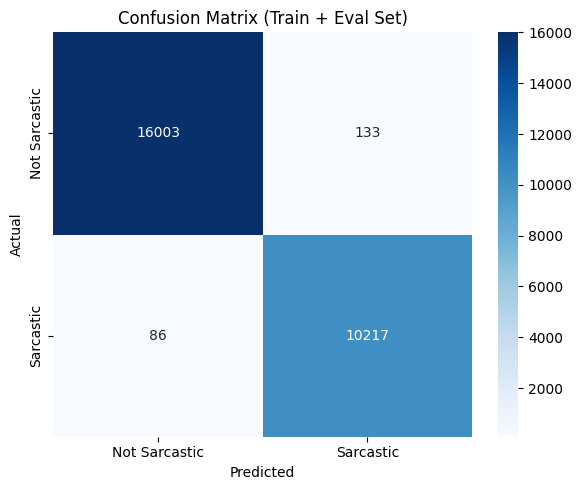

Saved confusion matrix to /content/drive/MyDrive/twitter-roberta-base/cv_sarcasm_optuna/final_saved_model/png/train_eval_confusion_matrix.png

========== EVALUATION STATISTICS ==========
Total Samples:   26439
Threshold:       0.4
Accuracy:        0.9917
Precision:       0.9871
Recall:          0.9917
F1 Score:        0.9894
ROC-AUC:         0.9995
True Negatives:  16003
False Positives: 133
False Negatives: 86
True Positives:  10217


In [12]:
import os
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# Paths
model_dir = "/content/drive/MyDrive/twitter-roberta-base/cv_sarcasm_optuna/final_saved_model"
data_dir = "/content/drive/MyDrive/processed_data"
png_dir = os.path.join(model_dir, "png")
os.makedirs(png_dir, exist_ok=True)

# Load inference config
with open(os.path.join(model_dir, "inference_config.json"), "r") as f:
    infer_cfg = json.load(f)

threshold = infer_cfg["selected_threshold"]
max_length = infer_cfg["max_length"]

# Load Model and Tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
model.to(device)
model.eval()

# Load and prepare Data
train_df = pd.read_csv(os.path.join(data_dir, "train_split.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "val_split.csv"))
combined_df = pd.concat([train_df, val_df], ignore_index=True)

combined_df.dropna(subset=["cleaned_text", "Sarcastic"], inplace=True)
combined_df["cleaned_text"] = combined_df["cleaned_text"].astype(str).str.strip()
combined_df["Sarcastic"] = pd.to_numeric(combined_df["Sarcastic"], errors="coerce")
combined_df.dropna(subset=["Sarcastic"], inplace=True)
combined_df["Sarcastic"] = combined_df["Sarcastic"].astype(int)

texts = combined_df["cleaned_text"].tolist()
labels = combined_df["Sarcastic"].tolist()

# Dataset & DataLoader for batching
class SimpleDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

dataset = SimpleDataset(texts, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# Run Inference
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_texts, batch_labels in tqdm(dataloader, desc="Evaluating"):
        enc = tokenizer(
            list(batch_texts),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)

        outputs = model(**enc)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(batch_labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= threshold).astype(int)

# Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Train + Eval Set)')
plt.tight_layout()

# Save PNG
save_path = os.path.join(png_dir, "train_eval_confusion_matrix.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Saved confusion matrix to {save_path}\n")

# Calculate and print useful statistics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
roc_auc = roc_auc_score(all_labels, all_probs)

print("========== EVALUATION STATISTICS ==========")
print(f"Total Samples:   {len(all_labels)}")
print(f"Threshold:       {threshold}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision:       {prec:.4f}")
print(f"Recall:          {rec:.4f}")
print(f"F1 Score:        {f1:.4f}")
print(f"ROC-AUC:         {roc_auc:.4f}")
print(f"True Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 92/92 [00:10<00:00,  8.50it/s]


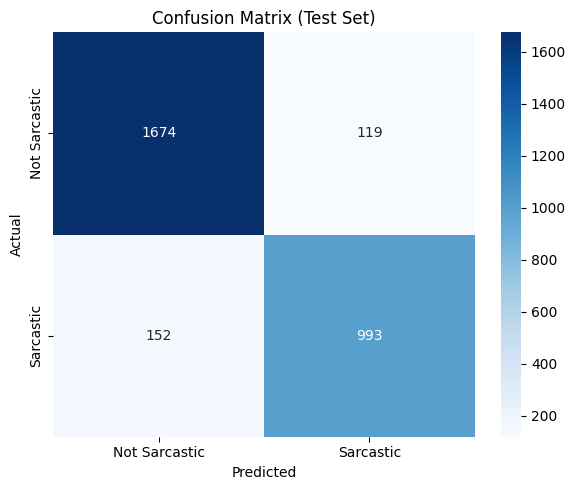

Saved confusion matrix to /content/drive/MyDrive/twitter-roberta-base/cv_sarcasm_optuna/final_saved_model/png/test_confusion_matrix.png

========== EVALUATION STATISTICS ==========
Total Samples:   2938
Threshold:       0.4
Accuracy:        0.9078
Precision:       0.8930
Recall:          0.8672
F1 Score:        0.8799
ROC-AUC:         0.9647
True Negatives:  1674
False Positives: 119
False Negatives: 152
True Positives:  993


In [13]:
import os
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# Paths
model_dir = "/content/drive/MyDrive/twitter-roberta-base/cv_sarcasm_optuna/final_saved_model"
data_dir = "/content/drive/MyDrive/processed_data"
png_dir = os.path.join(model_dir, "png")
os.makedirs(png_dir, exist_ok=True)

# Load inference config
with open(os.path.join(model_dir, "inference_config.json"), "r") as f:
    infer_cfg = json.load(f)

threshold = infer_cfg["selected_threshold"]
max_length = infer_cfg["max_length"]

# Load Model and Tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
model.to(device)
model.eval()

# Load and prepare Data
test_df = pd.read_csv(os.path.join(data_dir, "test_split.csv"))

test_df.dropna(subset=["cleaned_text", "Sarcastic"], inplace=True)
test_df["cleaned_text"] = test_df["cleaned_text"].astype(str).str.strip()
test_df["Sarcastic"] = pd.to_numeric(test_df["Sarcastic"], errors="coerce")
test_df.dropna(subset=["Sarcastic"], inplace=True)
test_df["Sarcastic"] = test_df["Sarcastic"].astype(int)

texts = test_df["cleaned_text"].tolist()
labels = test_df["Sarcastic"].tolist()

# Dataset & DataLoader for batching
class SimpleDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

dataset = SimpleDataset(texts, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# Run Inference
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_texts, batch_labels in tqdm(dataloader, desc="Evaluating"):
        enc = tokenizer(
            list(batch_texts),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)

        outputs = model(**enc)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(batch_labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= threshold).astype(int)

# Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()

# Save PNG
save_path = os.path.join(png_dir, "test_confusion_matrix.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Saved confusion matrix to {save_path}\n")

# Calculate and print useful statistics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
roc_auc = roc_auc_score(all_labels, all_probs)

print("========== EVALUATION STATISTICS ==========")
print(f"Total Samples:   {len(all_labels)}")
print(f"Threshold:       {threshold}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision:       {prec:.4f}")
print(f"Recall:          {rec:.4f}")
print(f"F1 Score:        {f1:.4f}")
print(f"ROC-AUC:         {roc_auc:.4f}")
print(f"True Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 827/827 [01:36<00:00,  8.58it/s]


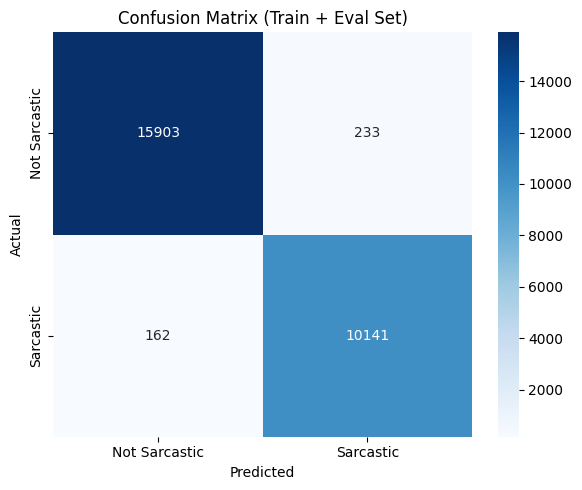

Saved confusion matrix to /content/drive/MyDrive/twitter-roberta-base-irony/cv_sarcasm_optuna/final_saved_model/png/train_eval_confusion_matrix.png

========== EVALUATION STATISTICS ==========
Total Samples:   26439
Threshold:       0.4
Accuracy:        0.9851
Precision:       0.9775
Recall:          0.9843
F1 Score:        0.9809
ROC-AUC:         0.9983
True Negatives:  15903
False Positives: 233
False Negatives: 162
True Positives:  10141


In [14]:
import os
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# Paths
model_dir = "/content/drive/MyDrive/twitter-roberta-base-irony/cv_sarcasm_optuna/final_saved_model"
data_dir = "/content/drive/MyDrive/processed_data"
png_dir = os.path.join(model_dir, "png")
os.makedirs(png_dir, exist_ok=True)

# Load inference config
with open(os.path.join(model_dir, "inference_config.json"), "r") as f:
    infer_cfg = json.load(f)

threshold = infer_cfg["selected_threshold"]
max_length = infer_cfg["max_length"]

# Load Model and Tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
model.to(device)
model.eval()

# Load and prepare Data
train_df = pd.read_csv(os.path.join(data_dir, "train_split.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "val_split.csv"))
combined_df = pd.concat([train_df, val_df], ignore_index=True)

combined_df.dropna(subset=["cleaned_text", "Sarcastic"], inplace=True)
combined_df["cleaned_text"] = combined_df["cleaned_text"].astype(str).str.strip()
combined_df["Sarcastic"] = pd.to_numeric(combined_df["Sarcastic"], errors="coerce")
combined_df.dropna(subset=["Sarcastic"], inplace=True)
combined_df["Sarcastic"] = combined_df["Sarcastic"].astype(int)

texts = combined_df["cleaned_text"].tolist()
labels = combined_df["Sarcastic"].tolist()

# Dataset & DataLoader for batching
class SimpleDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

dataset = SimpleDataset(texts, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# Run Inference
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_texts, batch_labels in tqdm(dataloader, desc="Evaluating"):
        enc = tokenizer(
            list(batch_texts),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)

        outputs = model(**enc)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(batch_labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= threshold).astype(int)

# Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Train + Eval Set)')
plt.tight_layout()

# Save PNG
save_path = os.path.join(png_dir, "train_eval_confusion_matrix.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Saved confusion matrix to {save_path}\n")

# Calculate and print useful statistics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
roc_auc = roc_auc_score(all_labels, all_probs)

print("========== EVALUATION STATISTICS ==========")
print(f"Total Samples:   {len(all_labels)}")
print(f"Threshold:       {threshold}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision:       {prec:.4f}")
print(f"Recall:          {rec:.4f}")
print(f"F1 Score:        {f1:.4f}")
print(f"ROC-AUC:         {roc_auc:.4f}")
print(f"True Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 92/92 [00:10<00:00,  8.74it/s]


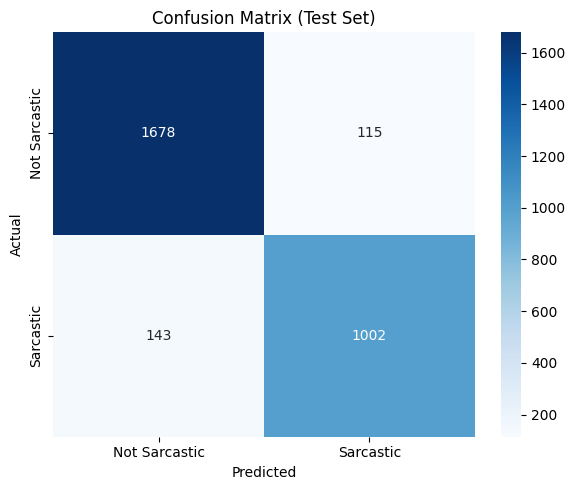

Saved confusion matrix to /content/drive/MyDrive/twitter-roberta-base-irony/cv_sarcasm_optuna/final_saved_model/png/test_confusion_matrix.png

========== EVALUATION STATISTICS ==========
Total Samples:   2938
Threshold:       0.4
Accuracy:        0.9122
Precision:       0.8970
Recall:          0.8751
F1 Score:        0.8859
ROC-AUC:         0.9671
True Negatives:  1678
False Positives: 115
False Negatives: 143
True Positives:  1002


In [15]:
import os
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# Paths
model_dir = "/content/drive/MyDrive/twitter-roberta-base-irony/cv_sarcasm_optuna/final_saved_model"
data_dir = "/content/drive/MyDrive/processed_data"
png_dir = os.path.join(model_dir, "png")
os.makedirs(png_dir, exist_ok=True)

# Load inference config
with open(os.path.join(model_dir, "inference_config.json"), "r") as f:
    infer_cfg = json.load(f)

threshold = infer_cfg["selected_threshold"]
max_length = infer_cfg["max_length"]

# Load Model and Tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
model.to(device)
model.eval()

# Load and prepare Data
test_df = pd.read_csv(os.path.join(data_dir, "test_split.csv"))

test_df.dropna(subset=["cleaned_text", "Sarcastic"], inplace=True)
test_df["cleaned_text"] = test_df["cleaned_text"].astype(str).str.strip()
test_df["Sarcastic"] = pd.to_numeric(test_df["Sarcastic"], errors="coerce")
test_df.dropna(subset=["Sarcastic"], inplace=True)
test_df["Sarcastic"] = test_df["Sarcastic"].astype(int)

texts = test_df["cleaned_text"].tolist()
labels = test_df["Sarcastic"].tolist()

# Dataset & DataLoader for batching
class SimpleDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

dataset = SimpleDataset(texts, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# Run Inference
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_texts, batch_labels in tqdm(dataloader, desc="Evaluating"):
        enc = tokenizer(
            list(batch_texts),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)

        outputs = model(**enc)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(batch_labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= threshold).astype(int)

# Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()

# Save PNG
save_path = os.path.join(png_dir, "test_confusion_matrix.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Saved confusion matrix to {save_path}\n")

# Calculate and print useful statistics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
roc_auc = roc_auc_score(all_labels, all_probs)

print("========== EVALUATION STATISTICS ==========")
print(f"Total Samples:   {len(all_labels)}")
print(f"Threshold:       {threshold}")
print(f"Accuracy:        {acc:.4f}")
print(f"Precision:       {prec:.4f}")
print(f"Recall:          {rec:.4f}")
print(f"F1 Score:        {f1:.4f}")
print(f"ROC-AUC:         {roc_auc:.4f}")
print(f"True Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")
